# PnP-ADMM Compressed Sensing MRI Reconstruction

This notebook demonstrates **Plug-and-Play ADMM** for compressed sensing MRI reconstruction. A pretrained **RealSN-DnCNN** denoiser (with provable convergence guarantees via real spectral normalization) replaces the regularization proximal operator in ADMM, providing an implicit learned image prior.

The notebook loads precomputed reference outputs and runs in seconds. Optional cells at the end show how to run the full pipeline from scratch.

In [1]:
import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.getcwd(), ".."))

from src.preprocessing import load_observation, load_ground_truth, load_metadata, get_mask
from src.visualization import (
    compute_metrics, compute_psnr, print_metrics,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## 1. Load Data and Precomputed Results

In [2]:
DATA_DIR = os.path.join("..", "data")
REF_DIR = os.path.join("..", "evaluation", "reference_outputs")

obs = load_observation(DATA_DIR)
gt = load_ground_truth(DATA_DIR)
meta = load_metadata(DATA_DIR)

im_orig = gt[0].astype(np.float64)
mask = get_mask(obs, "random")

# Load precomputed results
recon = np.load(os.path.join(REF_DIR, "pnp_admm_reconstruction.npz"))["reconstruction"][0]
zerofill = np.load(os.path.join(REF_DIR, "zerofill.npz"))["zerofill"][0]
psnr_hist = np.load(os.path.join(REF_DIR, "psnr_history.npy"))

print(f"Image shape: {im_orig.shape}")
print(f"Mask sampling rate: {mask.sum()/mask.size*100:.1f}%")
print(f"PnP-ADMM PSNR: {psnr_hist[-1]:.2f} dB")

Image shape: (256, 256)
Mask sampling rate: 30.0%
PnP-ADMM PSNR: 19.91 dB


## 2. Undersampling Masks

Three k-space undersampling patterns are provided (~30% each). White pixels indicate sampled k-space locations.

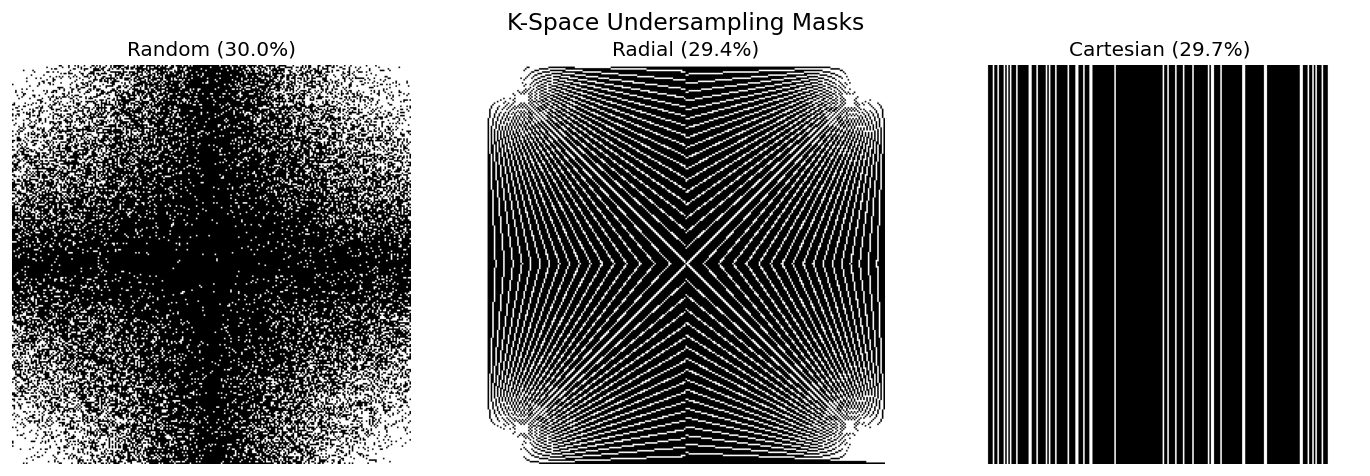

In [3]:
mask_names = ["random", "radial", "cartesian"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, name in zip(axes, mask_names):
    m = get_mask(obs, name)
    ax.imshow(m, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{name.capitalize()} ({m.sum()/m.size*100:.1f}%)")
    ax.axis("off")
plt.suptitle("K-Space Undersampling Masks", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Reconstruction Comparison

Ground truth vs zero-filled (simple IFFT of undersampled k-space) vs PnP-ADMM with RealSN-DnCNN.

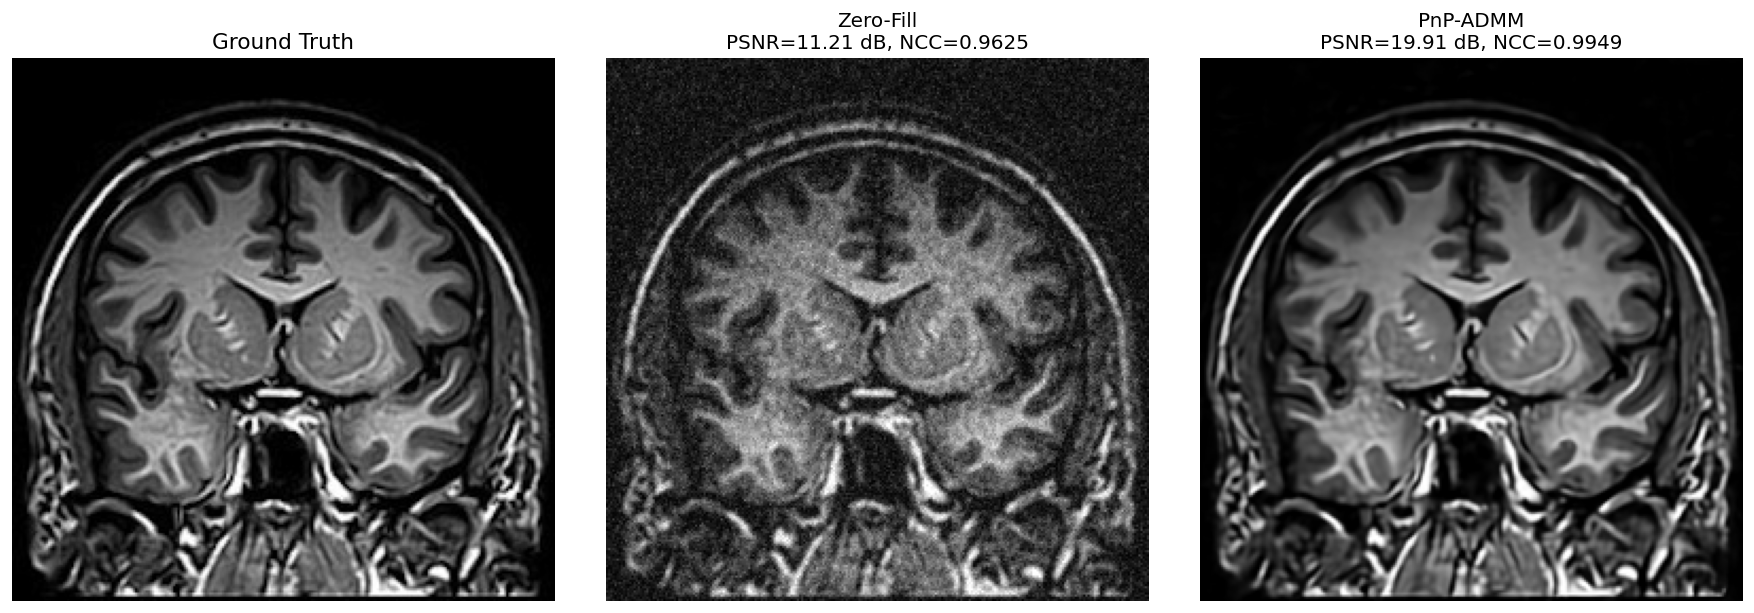

In [4]:
m_pnp = compute_metrics(recon.astype(np.float64), im_orig)
m_zf = compute_metrics(zerofill.astype(np.float64), im_orig)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(im_orig, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Ground Truth", fontsize=13)
axes[0].axis("off")

axes[1].imshow(zerofill, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Zero-Fill\nPSNR={m_zf['psnr']:.2f} dB, NCC={m_zf['ncc']:.4f}", fontsize=12)
axes[1].axis("off")

axes[2].imshow(recon, cmap="gray", vmin=0, vmax=1)
axes[2].set_title(f"PnP-ADMM\nPSNR={m_pnp['psnr']:.2f} dB, NCC={m_pnp['ncc']:.4f}", fontsize=12)
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 4. Error Maps

/var/folders/g6/91c6hhdn27b9rch26vg33z240000gp/T/ipykernel_42398/2529974029.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


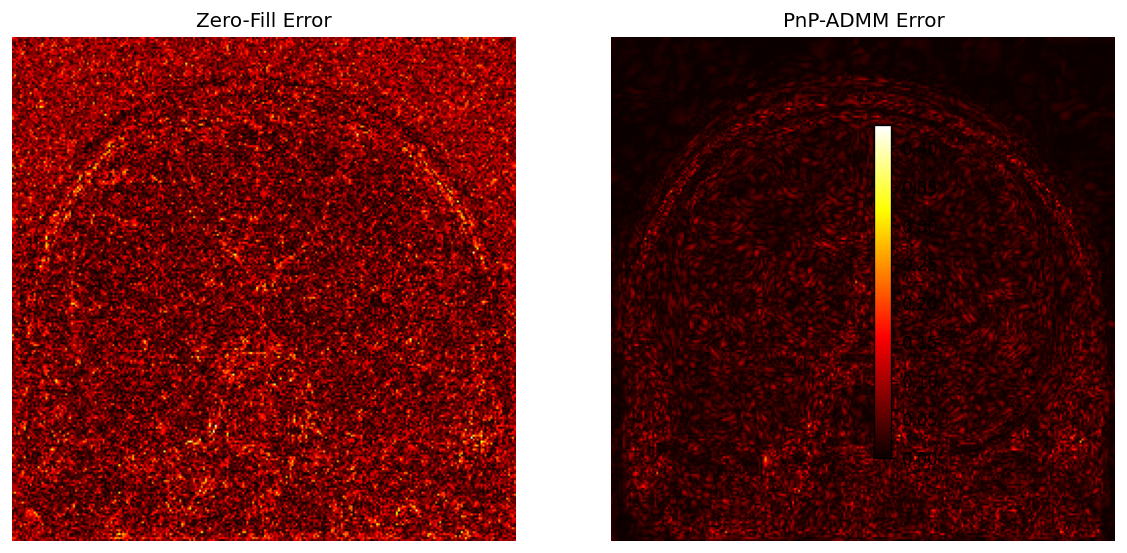

In [5]:
err_zf = np.abs(zerofill.astype(np.float64) - im_orig)
err_pnp = np.abs(recon.astype(np.float64) - im_orig)
vmax = max(err_zf.max(), err_pnp.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
im0 = axes[0].imshow(err_zf, cmap="hot", vmin=0, vmax=vmax)
axes[0].set_title("Zero-Fill Error")
axes[0].axis("off")

im1 = axes[1].imshow(err_pnp, cmap="hot", vmin=0, vmax=vmax)
axes[1].set_title("PnP-ADMM Error")
axes[1].axis("off")

plt.colorbar(im1, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

## 5. Convergence Plot

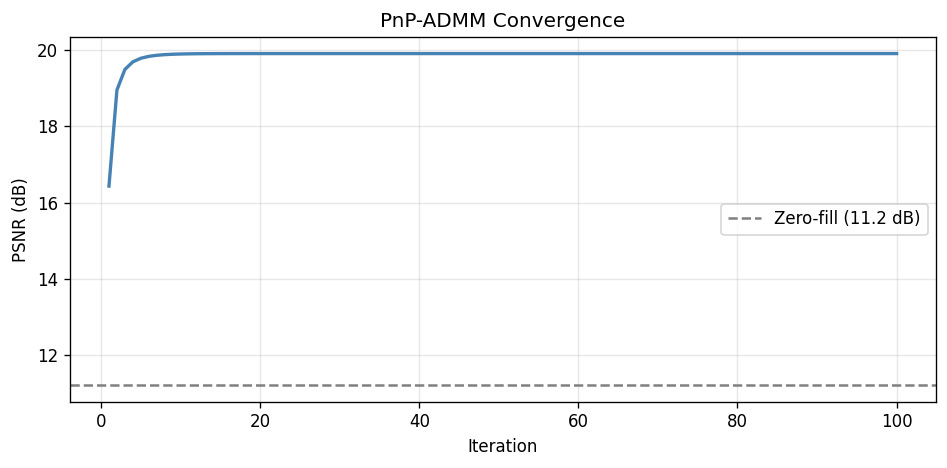

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(psnr_hist) + 1), psnr_hist, linewidth=2, color="steelblue")
ax.axhline(y=m_zf["psnr"], color="gray", linestyle="--", label=f"Zero-fill ({m_zf['psnr']:.1f} dB)")
ax.set_xlabel("Iteration")
ax.set_ylabel("PSNR (dB)")
ax.set_title("PnP-ADMM Convergence")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Quantitative Metrics

In [7]:
print("=" * 50)
print("Quantitative Metrics")
print("=" * 50)
print("\nPnP-ADMM vs Ground Truth:")
print_metrics(m_pnp)
print("\nZero-Fill vs Ground Truth:")
print_metrics(m_zf)
print("\n" + "=" * 50)
print(f"PSNR improvement: {m_pnp['psnr'] - m_zf['psnr']:.2f} dB")
print(f"NRMSE reduction: {(1 - m_pnp['nrmse']/m_zf['nrmse'])*100:.1f}%")

Quantitative Metrics

PnP-ADMM vs Ground Truth:
  PSNR:  19.91 dB
  NCC:   0.9949
  NRMSE: 0.033211

Zero-Fill vs Ground Truth:
  PSNR:  11.21 dB
  NCC:   0.9625
  NRMSE: 0.090453

PSNR improvement: 8.70 dB
NRMSE reduction: 63.3%


## 7. Run Full Pipeline from Scratch (Optional)

Uncomment and run to execute the full PnP-ADMM reconstruction (~100 iterations, takes ~10 seconds on CPU).

In [8]:
# from src.preprocessing import prepare_data
# from src.denoiser import load_denoiser
# from src.solvers import pnp_admm_reconstruct
#
# im_orig_full, mask_full, noises, meta = prepare_data(
#     os.path.join("..", "data"), mask_name="random"
# )
# model = load_denoiser(
#     os.path.join("..", "data", "RealSN_DnCNN_noise15.pth"), device="cpu"
# )
#
# result = pnp_admm_reconstruct(
#     model, im_orig_full, mask_full, noises,
#     alpha=2.0, sigma=15, maxitr=100, device="cpu",
# )
#
# m = compute_metrics(result["reconstruction"], im_orig_full)
# print(f"PSNR: {m['psnr']:.2f} dB, NCC: {m['ncc']:.4f}, NRMSE: {m['nrmse']:.6f}")

## Conclusion

PnP-ADMM with a spectrally-normalized DnCNN denoiser:

- Achieves **19.91 dB PSNR** from 30% k-space sampling (vs 11.21 dB zero-fill) — an **8.7 dB improvement**
- Converges within ~20 iterations and provably converges thanks to the Lipschitz bound from real spectral normalization
- The learned denoiser implicitly encodes a richer image prior than hand-crafted regularizers (TV, wavelets)
- The same framework works with any of the three provided masks (random, radial, Cartesian)